# Lab 8

In [3]:
### MATPLOTLIB SETUP ###
import math
from math import sqrt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import curve_fit
import sys
pd.set_option('display.float_format', lambda x: '%e' % x)

## Amit's library with some utility functions for reading and processing scope data; reproduced below
sys.path.append("../../")
from lib import *

from rich.console import Console
from rich.syntax import Syntax
Console().print(Syntax.from_path("../../lib.py", line_numbers=True, theme="monokai"))

## Jupyter magic
%matplotlib
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

    1 import csv                                                                                                   
    2 import pandas as pd                                                                                          
    3 import numpy as np                                                                                           
    4 from scipy.signal import find_peaks                                                                          
    5                                                                                                              
    6 R = 5 # Load Resistance                                                                                      
    7 VG = 18 # Input Voltage                                                                                      
    8 Fs = 50500 # Measured frequency                                                                              
    9 Ts = 1/ Fs                                                                                                   
   10 R_SHUNT = 0.05 # from schematic                                                                              
   11                                                                                                              
   12 # read funky Rigol CSV format                                                                                
   13 def read_rigol_csv(csv_file_name):                                                                           
   14     with open(csv_file_name) as f:                                                                           
   15         rows = list(csv.reader(f))                                                                           
   16         i = 0                                                                                                
   17         while rows[0][i] != "":                                                                              
   18             i = i+1                                                                                          
   19         numcols = i-2                                                                                        
   20         t0 = float(rows[1][numcols])                                                                         
   21         dT = float(rows[1][numcols+1])                                                                       
   22                                                                                                              
   23     data = pd.read_csv(csv_file_name, usecols=range(0,numcols), skiprows=[1])                                
   24     data['X'] = t0+data['X']*dT                                                                              
   25     return data, t0, dT                                                                                      
   26                                                                                                              
   27 def import_and_clean(name, cols, filt, filt_len=10):                                                         
   28     """                                                                                                      
   29     Import and clean some data from the Rigol scope                                                          
   30                                                                                                              
   31     @param name: name of csv file (assumed to live in `./data`)                                              
   32     @param cols: what to rename columns to                                                                   
   33     @param filt: whether to

Using matplotlib backend: module://matplotlib_inline.backend_inline


## Prelab

In this prelab, I will attempt to quantify the loss in various components of our converter to come up with an estimate of the total losses.

### FET losses

**Conduction losses**

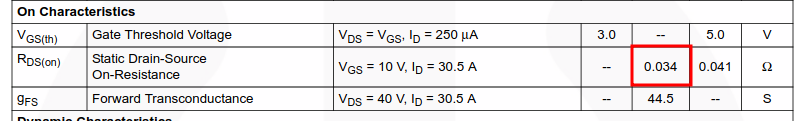

Looking at the datasheet for our FET, I found the FET drain-source resistance to be about 0.034 ohms. Using the equation (and the peak current from previous lab)

$$I_{rms} = \sqrt{\frac{D}{3}} \cdot I_{pk}$$

Using the

$$
P = I^2 R
$$

formula for power dissipated by a resistor, we can approximate our FET conduction loss as

In [4]:
D = 0.35
Ipk = 7.24
Rds = 0.034
Irms = np.sqrt(D/3) * Ipk
FET_conduction = Irms**2 * Rds
print(f"FET Conduction loss {FET_conduction}W")

FET Conduction loss 0.2079231466666667W


**Switching losses**

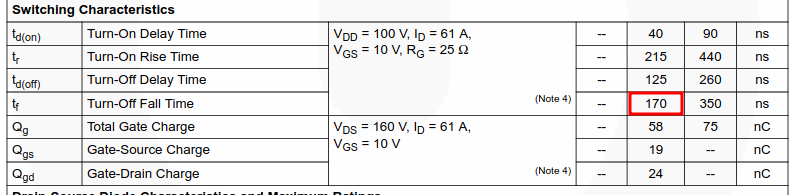

Looking at the datasheet, the turn-off time of the FET is 170ns, which I can plug into this equation for FET switching loss

$$
P = \frac{1}{2} \cdot V_g \cdot I_{pk} \cdot t_f \cdot F_s
$$

where $t_f$ is fall time. This calculation is in the code cell below

In [5]:
tf = 170e-9
FET_switching = 0.5 * VG * Ipk * tf * Fs
print(f"FET Switching loss {FET_switching}W")

FET Switching loss 0.5593985999999999W


### Transformer Losses

**Winding conduction loss**

Firstly, we estimated our transformer winding resistance for the primary and secondary winding by meausring it with a Keithley SourceMeter, then also measuring the resistance of our two alligator clips shorted together and taking the difference.

This gave us resistance values of $0.316 - 0.2925 = .024 \Omega$ for the primary winding and $0.309 - 0.2925 = .017 \Omega$. This makes some sense, as I'd expect the shorter secondary winding with less turns to have a lower resistance. Using the same power dissipation over a resistor equation, with our primary RMS current for the primary winding, and the same current transformed by the turns ratio for the secondary winding, I estimate the winding conduction loss to be

In [6]:
a = 0.63
R_prim = 0.024
R_second = 0.017
Irms_second = Irms / a

Transformer_winding = Irms**2 * R_prim + (Irms_second**2) * R_second
print(f"Transformer winding loss {Transformer_winding}W")

Transformer winding loss 0.4087032012228101W


**Core losses**

From our previus labs, we calculated our RMS flux density to be about 0.091T. Looking at this graph from the PC95 material sheet, it would seem that operating at 50kHz at the lower temperature line, the typical core losses are about 11 kW / m^3

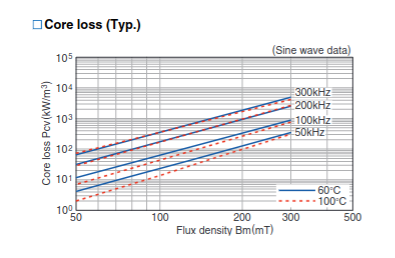

Taking the effective volume from the core datasheet as 2850 mm^3, a little bit of unit conversion gets us our approximate core loss.

In [7]:
Veq = 2850 # mm^3
Veq *= 1e-9 # m^3
Transformer_core = 11 * Veq * 1000
print(f"Transformer core loss {Transformer_core}W")

Transformer core loss 0.03135W


### Rectifying Diode

Because this is a schottkey diode, the switching losses should be negligible since there is almost no reverse recovery effect. 

However, there are some conduction losses - to find them, we can use the $P = IV$ equation. The current I was able to approximate by adding an ammeter to my PLECS sim (1.16A), and by looking at this graph in the datasheet and finding the point on the curve where the lower 25C curve reaches 2 amps of current, we can take a value of about 0.5V for the forward voltage.

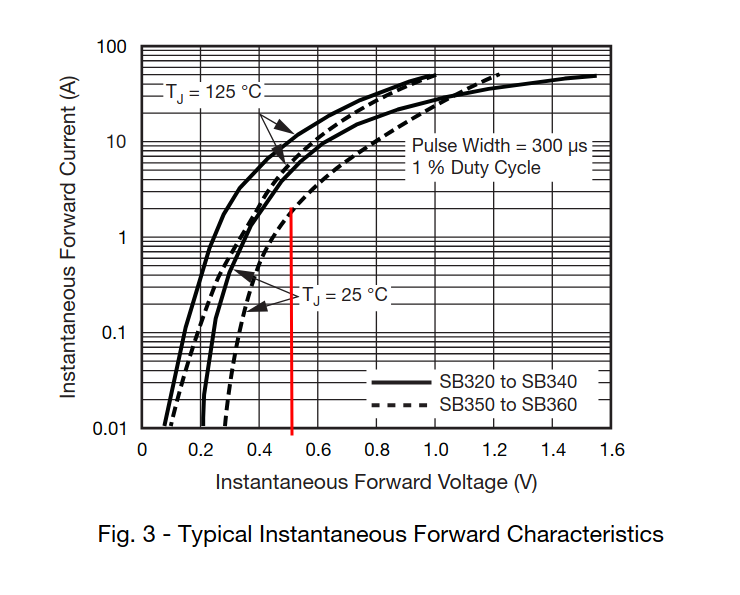

This give a total conduction loss of

In [8]:
Rectifying_diode = 1.16 * 0.5
print(f"Rectifying diode conduction loss {Rectifying_diode}W")

Rectifying diode conduction loss 0.58W


### RCD Clamp

In Lab 7, we calculated the power dissipated over the clamp resistor to be 0.817W

In [9]:
clamp_loss = 0.817
print(f"RCD Clamp resistor loss {clamp_loss}W")

RCD Clamp resistor loss 0.817W


### RC Snubber

Firstly, I used PLECS to find the RMS current through my snubber to be 27.4mA. I can use $P = I^2 R$ to find the loss through the resistor, with our known HF snubber resistance of 22 Ohms

In [10]:
snubber_loss = .0274 ** 2 * 22
print(f"HF Snubber resistor loss {snubber_loss}W")

HF Snubber resistor loss 0.016516720000000002W


## Pie Chart

Total loss 2.620891667889476W


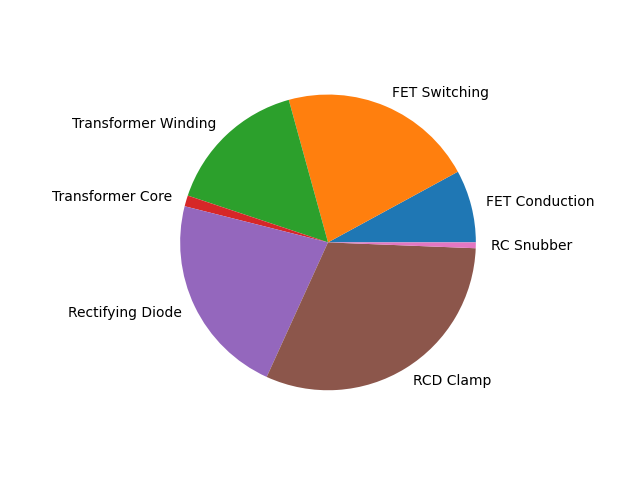

In [11]:
sizes = [FET_conduction, FET_switching, Transformer_winding, Transformer_core, Rectifying_diode, clamp_loss, snubber_loss]
labels = ["FET Conduction", "FET Switching", "Transformer Winding", "Transformer Core", "Rectifying Diode", "RCD Clamp", "RC Snubber"]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels)

total_loss = sum(sizes)
print(f"Total loss {total_loss}W")

Based on our previous lab's data, our converter operated at 18V/1.5A input, or 27W in. If we have 2.9W of loss, that would make our converter $\frac{27-2.9}{27} %$ efficient, which would be about 89%. To be honest, this sounds a bit high, so I'm expecting that over the lab we might find some additional sources of loss, or realize some elements are higher than I would have originally thought.

In [12]:
eff_pre = (27-total_loss)/27
print(f"Efficiency: {round(eff_pre * 100, 2)}%")

Efficiency: 90.29%


# LAB

### Q1

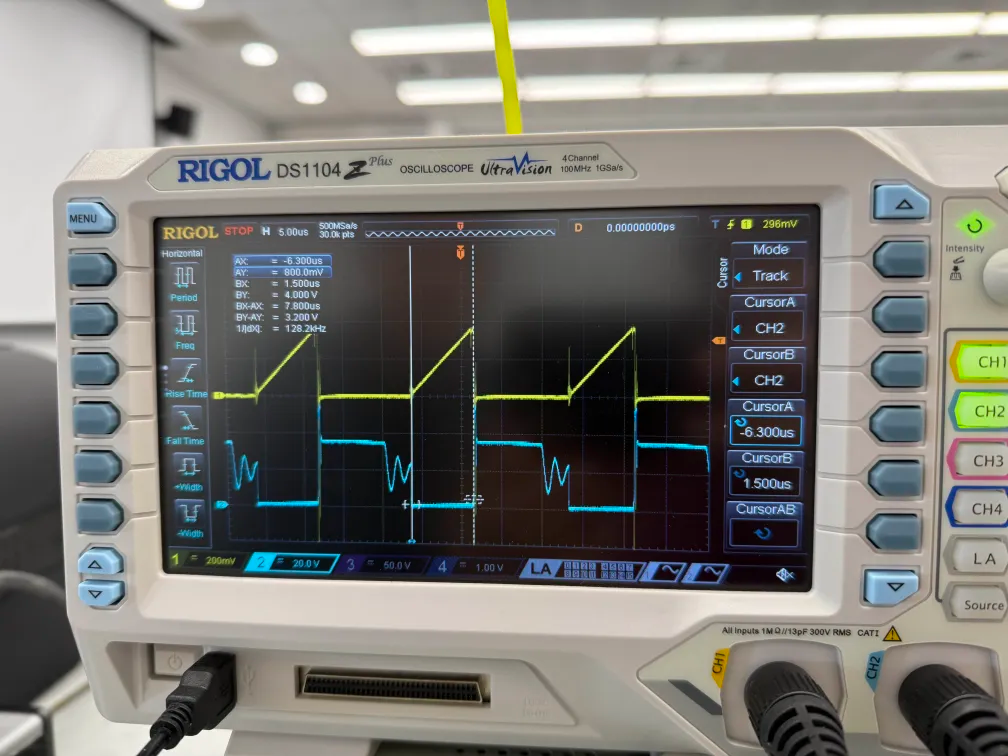

We used the cursor on our scope to manually verify our duty cycle. With an on time of 7.8 us, and a switching period of 20 us, that gives us a duty cycle of 39%, which we considered close enough to 35% to proceed.

In [13]:
print(f"{round(100 * 7.8/20, 2)}%")

39.0%


### Q2

With an input voltage of 18V, input current of 1.42A, and an output voltage of 10.01V, I calculated the power in as $P=IV$ and applied Ohm's law to calculate power out as $P = \frac{V^2}{R}$, then took the difference between them as our total power lost and used it to calculate an efficiency ratio. Based on this, it seems like my prelab calculation only accounted for about half this loss, so some components are probably underestimate or missing from this analysis

In [14]:
Iin = 1.42
Vout = 10.01
Pin = VG * Iin
Pout = Vout ** 2 / R
print(f"Power lost: {Pin - Pout}W")
print(f"Efficiency: {Pout / Pin}")

Power lost: 5.51998W
Efficiency: 0.7840383411580595


### Q3/4

The below code cell plots our shunt and drain voltages for progression of lower input voltages, as well as calculates the power loss and efficiency in the same way as above. Note that we reached a 50% duty cycle before entering BCM, so our final waveform is at VG = 14. Also, we slightly reduced our output voltage to 8.9V to ensure we began at a 35% duty cycle.

Power lost at 18v: 4.497999999999994W
Efficiency at 18v: 0.7788593903638154
Power lost at 17v: 5.067999999999998W
Efficiency at 17v: 0.7576279292204687
Power lost at 16v: 4.957999999999998W
Efficiency at 16v: 0.7616346153846155
Power lost at 15v: 5.457999999999995W
Efficiency at 15v: 0.7437558685446012
Power lost at 14v: 4.877999999999997W
Efficiency at 14v: 0.7645752895752898


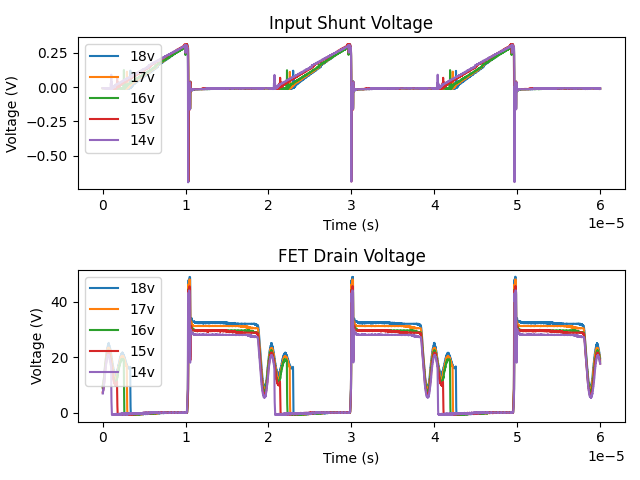

In [15]:
names = ['18v', '17v', '16v', '15v', '14v']
Iins = [1.13, 1.23, 1.30, 1.42, 1.48]
Vout = 8.9

fig, (ax1, ax2) = plt.subplots(2, 1)

for n, Vin, Iin in zip(names, range(18,13,-1), Iins):
    df, dt = import_and_clean(n, ["Vshunt", "Vdrain"], True)
    df.plot(x='X', y='Vshunt', ax=ax1, title="Input Shunt Voltage")
    df.plot(x='X', y='Vdrain', ax=ax2, title="FET Drain Voltage")

    Pin = Vin * Iin
    Pout = Vout ** 2 / R
    print(f"Power lost at {n}: {Pin - Pout}W")
    print(f"Efficiency at {n}: {Pout / Pin}")
    print("="*40)
    
ax1.set_xlabel("Time (s)")
ax2.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
ax2.set_ylabel("Voltage (V)")
ax1.legend(names, loc="upper left")
ax2.legend(names)

fig.tight_layout()

### Q5

Using the Flir camera, we captured a few thermal images of our converter's operation

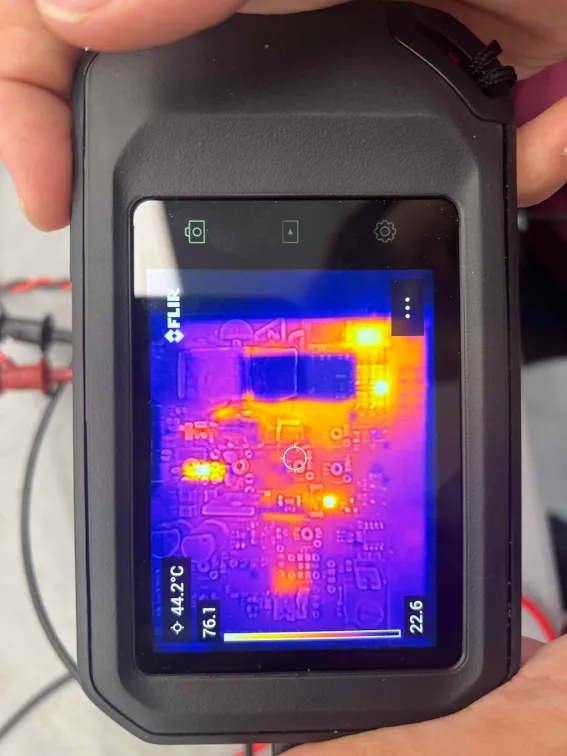
Top view

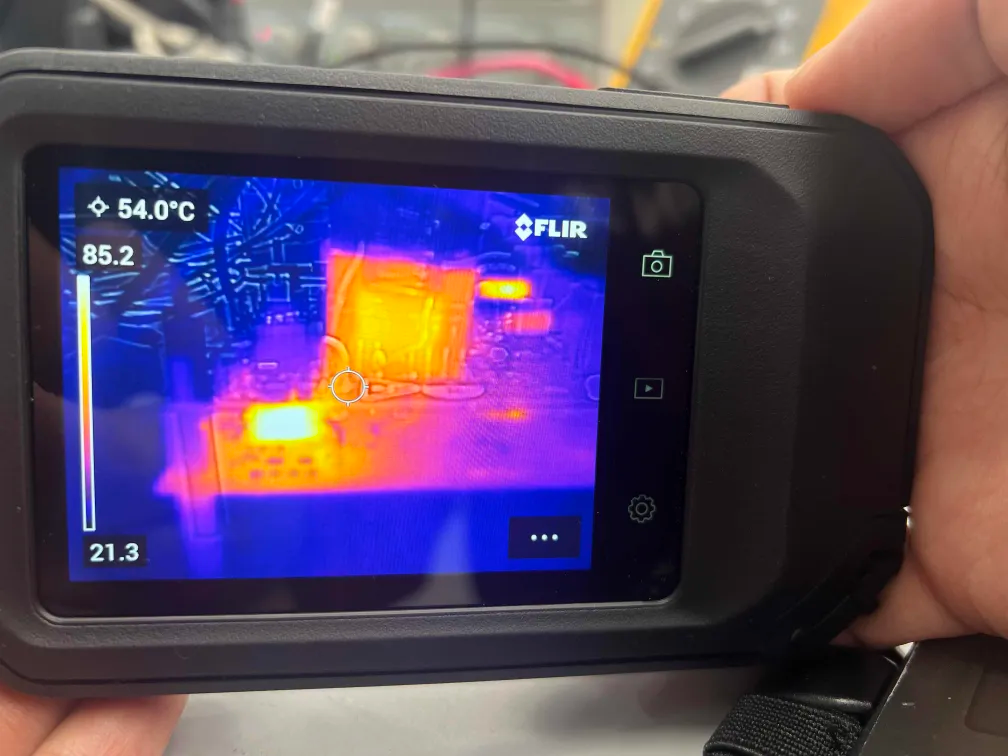
Transformer side view

The heat producing components we identified were
- Output and input shunt resistors
- Rectifying Diode
- MOSFET
- Clamp Resistor
- UC2844
- Transformer

### Q7

For this question, I reran my all of my loss calculations from the prelab, substituting measurements from the lab data where appropriate.

In [16]:
D = 0.46
Ipk = 4.66
Rds = 0.034
Irms = np.sqrt(D/3) * Ipk
FET_conduction = Irms**2 * Rds
print(f"FET Conduction loss {FET_conduction}W")

tf = 170e-9
FET_switching = 0.5 * VG * Ipk * tf * Fs
print(f"FET Switching loss {FET_switching}W")

a = 0.63
R_prim = 0.024
R_second = 0.017
Irms_second = Irms / a

Transformer_winding = Irms**2 * R_prim + (Irms_second**2) * R_second
print(f"Transformer winding loss {Transformer_winding}W")

Veq = 2850 # mm^3
Veq *= 1e-9 # m^3
Transformer_core = 11 * Veq * 1000
print(f"Transformer core loss {Transformer_core}W")


## Changed from prelab to use a valuefrom our actual circuit rather than a 
Rectifying_diode = Irms_second * 0.5
print(f"Rectifying diode conduction loss {Rectifying_diode}W")

clamp_loss = 0.817
print(f"RCD Clamp resistor loss {clamp_loss}W")

snubber_loss = .0274 ** 2 * 22
print(f"HF Snubber resistor loss {snubber_loss}W")

FET Conduction loss 0.11321066133333337W
FET Switching loss 0.36005489999999996W
Transformer winding loss 0.22253202897925592W
Transformer core loss 0.03135W
Rectifying diode conduction loss 1.448217062963852W
RCD Clamp resistor loss 0.817W
HF Snubber resistor loss 0.016516720000000002W


### Q8
Additionally, after looking at our FLIR photos, I realized we didn't initially account for the loss through either of the shunts, so I calculated those losses as $P = I^2R$.

I also calculated the loss through the LED as $P=IV$ where I = 20mA and V = 2.1V per the LED datasheet

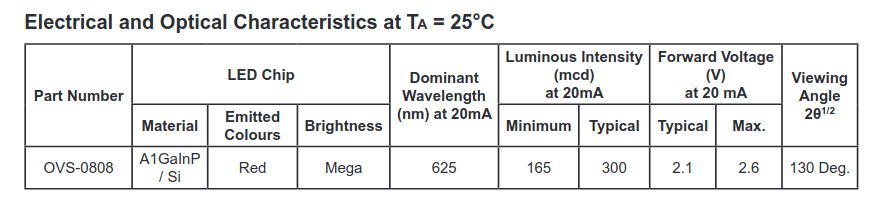

Lastly, I looked in the datasheet for the UC2844 to find its supply current and multiplied it with the input voltage to find its power consumption

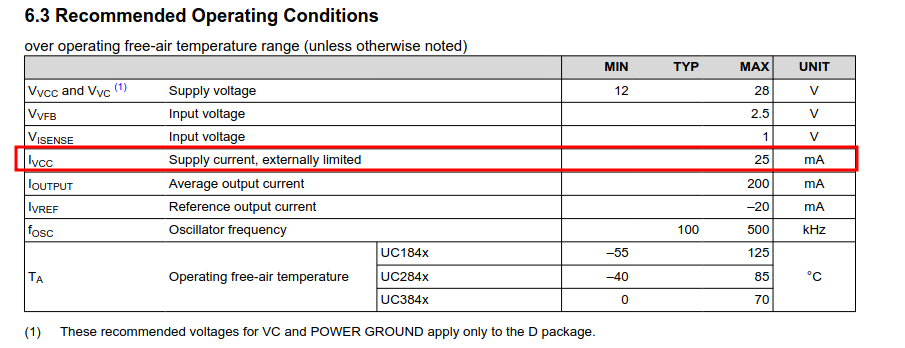

In [17]:
input_shunt = Irms ** 2 * R_SHUNT
output_shunt = (10.01/5) ** 2 * R_SHUNT
print(f"Input shunt loss {input_shunt}W")
print(f"Output shunt loss {output_shunt}W")

led = 0.02 * 2.1 * 2 # Green and red LEDs have the same current/voltage
print(f"Red LED loss {led}W")

uc = 0.025 * 18
print(f"UC2844 loss {uc}W")

Input shunt loss 0.16648626666666672W
Output shunt loss 0.20040019999999995W
Red LED loss 0.084W
UC2844 loss 0.45W


With these new calculations, the below code cell regenerates the pie chart and calculates efficiency.

Total loss 3.909767839943108W
Efficiency: 0.8470356870131804


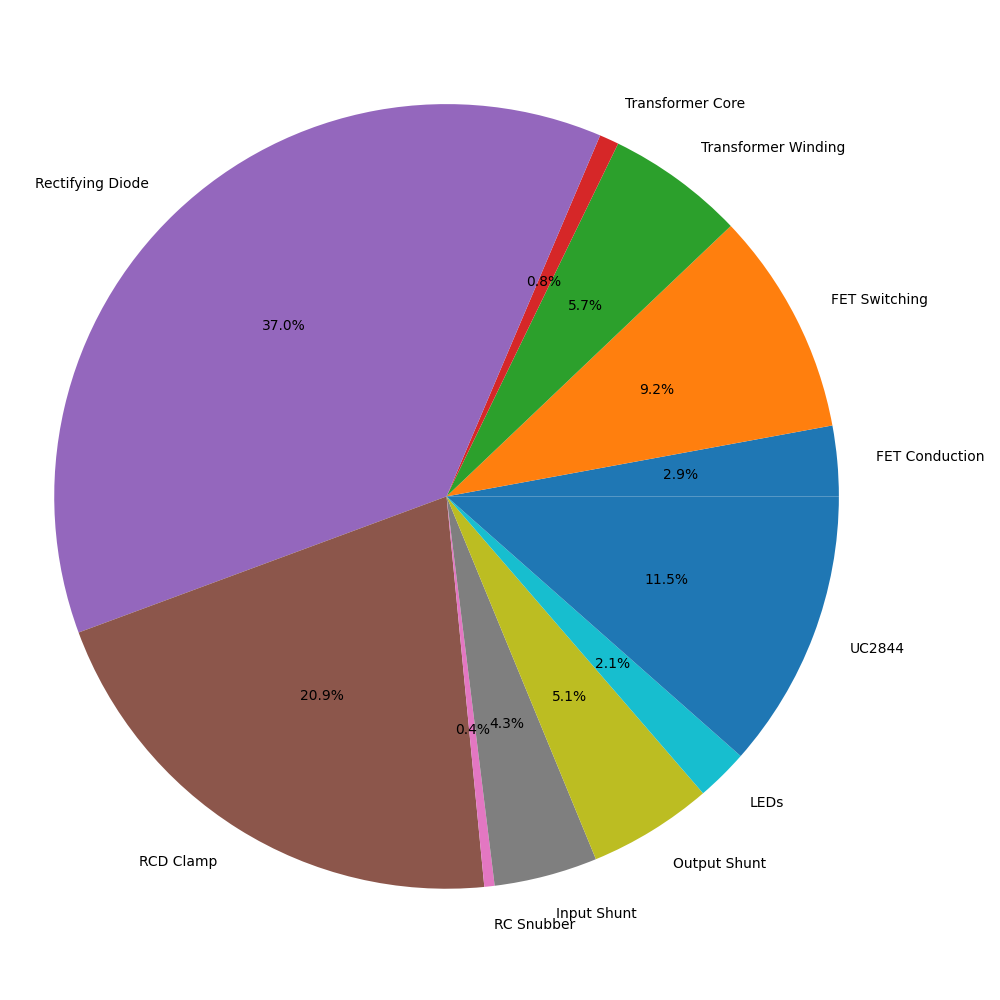

In [18]:
sizes = [FET_conduction, FET_switching, Transformer_winding, Transformer_core, Rectifying_diode, clamp_loss, snubber_loss, input_shunt, output_shunt, led, uc]
labels = ["FET Conduction", "FET Switching", "Transformer Winding", "Transformer Core", "Rectifying Diode", "RCD Clamp", "RC Snubber", "Input Shunt", "Output Shunt", "LEDs", "UC2844"]

fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.axis('equal')  
fig.tight_layout()

total_loss = sum(sizes)
print(f"Total loss {total_loss}W")

Iin = 1.42
Pin = VG * Iin
print(f"Efficiency: {(Pin-total_loss) / Pin}")

### Q11

Loss across input voltage for reference:

```
Power lost at 18v: 4.497999999999994W
Efficiency at 18v: 0.7788593903638154
========================================
Power lost at 17v: 5.067999999999998W
Efficiency at 17v: 0.7576279292204687
========================================
Power lost at 16v: 4.957999999999998W
Efficiency at 16v: 0.7616346153846155
========================================
Power lost at 15v: 5.457999999999995W
Efficiency at 15v: 0.7437558685446012
========================================
Power lost at 14v: 4.877999999999997W
Efficiency at 14v: 0.7645752895752898
========================================
```

As the input voltage steps down, there doesn't seem to be a clear trend in the losses in our power converter - between 18 and 14V the greatest deviation is about 3.5% or so. I would expect the relationship to trend only in one direction - that is, either strictly increasing or decreasing - however, our output voltage also shifted a bit when the input changed, and we moved it roughly back to 8.9V with the trim pot but there was likely some inaccuracy in this process that introduced a bit of jitter in our data.

### Q12

I'd expect the different loss types to be affected differently as the input voltage changes.

Our duty cycle increases as the input voltage decreases, which increases the time that the primary side of the circuit is conducting (and a higher RMS current). This means I'd expect more loss in components like the primary transformer winding/core, FET conduction, and shunt resistor. 

However, because the drain voltage is now lower, I'd expect the FET switching loss to go down, since the difference in the voltages that are being switched goes down.

Looking at the drain graphs, it seems that the rectifying diode on time is the same across all of our graphs, so I wouldn't expect those losses to be affected much. I'd also expect the clamp/snubber losses to be similar, since the clamp voltage is remaining the same (just getting offset slightly), and the snubber is still snubbing a similar HF ring.



### Q13

This doesn't tell us a ton of new information, since there isn't really a clear trend in our data one way or another. What we can infer is that the components that become lossier and a lower input are roughly evenly offset by those that become more efficient. The primary loss that decreases is the FET switching - because it has the input voltage as a multiplicative factor, decreasing input would have a fairly sizable effect. The other losses that increase with a higher duty cycle are smaller, but there are more of them so they end up roughly offsetting each other.

### Q14

I can think of a few different avenues to reduce our losses in this converter
- If we have more wiggle room to our transistor breakdown voltage, we can increase our clamping voltage to a higher value and dissipate less power over our clamp resistor
- If we used a thicker wire for our transformer, we'd reduce its resistance and therefore transformer winding losses (although we may introduce some skin effect loss)
- If we are ok with greater ripple, we could reduce our switching frequency to have less FET switching loss
- Remove the LEDs :)